<a href="https://colab.research.google.com/github/SiahCHangYEt/EA-Assignment/blob/main/EA_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running ACO Seeding...
Running Genetic Algorithm...
Gen 0: Best Dist = 523.99
Gen 20: Best Dist = 464.76
Gen 40: Best Dist = 460.92
Gen 60: Best Dist = 454.88
Gen 80: Best Dist = 453.04
Gen 100: Best Dist = 453.04


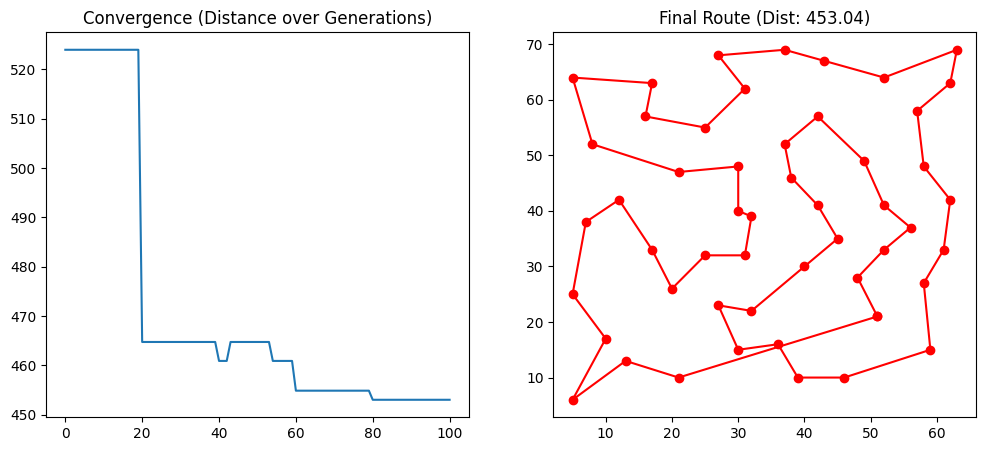

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# --- 1. COORDINATES & DISTANCE ---
# Using a small TSPLIB-style example (eil51 subset or similar)
cities = np.array([[37, 52], [49, 49], [52, 64], [20, 26], [40, 30], [21, 47], [17, 63], [31, 62], [52, 33], [51, 21], [42, 41], [31, 32], [5, 25], [12, 42], [36, 16], [52, 41], [27, 23], [17, 33], [13, 13], [57, 58], [62, 42], [42, 57], [16, 57], [8, 52], [7, 38], [27, 68], [30, 48], [43, 67], [58, 48], [58, 27], [37, 69], [38, 46], [46, 10], [61, 33], [62, 63], [63, 69], [32, 22], [45, 35], [59, 15], [5, 6], [10, 17], [21, 10], [5, 64], [30, 15], [39, 10], [32, 39], [25, 32], [25, 55], [48, 28], [56, 37], [30, 40]])

def get_dist_matrix(coords):
    n = len(coords)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            matrix[i][j] = np.linalg.norm(coords[i] - coords[j])
    return matrix

DIST_MATRIX = get_dist_matrix(cities)

def calc_total_dist(path):
    d = sum(DIST_MATRIX[path[i]][path[i+1]] for i in range(len(path)-1))
    d += DIST_MATRIX[path[-1]][path[0]]
    return d

# --- 2. ACO FOR SEEDING (The "Smart Start") ---
class SimpleACO:
    def __init__(self, n_ants=10, iterations=20):
        self.n_ants = n_ants
        self.iterations = iterations
        self.pheromones = np.ones((len(cities), len(cities)))

    def run(self):
        best_path = None
        best_dist = float('inf')
        for _ in range(self.iterations):
            paths = []
            for _ in range(self.n_ants):
                path = [random.randint(0, len(cities)-1)]
                while len(path) < len(cities):
                    curr = path[-1]
                    probs = []
                    for c in range(len(cities)):
                        if c not in path:
                            # Formula: pheromone * (1/dist)^2
                            probs.append(self.pheromones[curr][c] * (1.0/DIST_MATRIX[curr][c])**2)
                        else: probs.append(0)
                    next_c = random.choices(range(len(cities)), weights=probs)[0]
                    path.append(next_c)
                d = calc_total_dist(path)
                paths.append((path, d))
                if d < best_dist:
                    best_dist, best_path = d, path
            self.pheromones *= 0.9 # Evaporation
            for p, d in paths:
                for i in range(len(p)-1): self.pheromones[p[i]][p[i+1]] += (1.0/d)
        return best_path

# --- 3. GA OPERATORS ---
def cyclic_crossover(p1, p2):
    child = [-1] * len(p1)
    curr = 0
    while child[curr] == -1:
        child[curr] = p1[curr]
        curr = p1.index(p2[curr])
    for i in range(len(child)):
        if child[i] == -1: child[i] = p2[i]
    return child



def inversion_mutation(path):
    if random.random() < 0.1:
        i, j = sorted(random.sample(range(len(path)), 2))
        path[i:j] = path[i:j][::-1]
    return path

def tournament_selection(pop):
    candidates = random.sample(pop, 3)
    return min(candidates, key=lambda x: calc_total_dist(x))

# --- 4. 2-OPT LOCAL SEARCH (The "Finisher") ---
def two_opt(path):
    best = path
    for i in range(1, len(path) - 2):
        for j in range(i + 1, len(path)):
            new_path = best[:i] + best[i:j][::-1] + best[j:]
            if calc_total_dist(new_path) < calc_total_dist(best):
                best = new_path
    return best



# --- 5. MAIN EXECUTION ---
print("Running ACO Seeding...")
aco = SimpleACO()
seed_path = aco.run()

# Initialize GA Population with ACO seed
pop_size = 50
population = [inversion_mutation(seed_path[:]) for _ in range(pop_size)]

history = []
print("Running Genetic Algorithm...")
for gen in range(101):
    new_pop = []
    for _ in range(pop_size):
        p1, p2 = tournament_selection(population), tournament_selection(population)
        child = cyclic_crossover(p1, p2)
        child = inversion_mutation(child)
        new_pop.append(child)

    # 2-opt refinement on the best every 20 generations
    if gen % 20 == 0:
        best_ind = min(new_pop, key=calc_total_dist)
        new_pop[0] = two_opt(best_ind)

    population = new_pop
    best_d = calc_total_dist(min(population, key=calc_total_dist))
    history.append(best_d)
    if gen % 20 == 0: print(f"Gen {gen}: Best Dist = {best_d:.2f}")

# --- 6. PLOTTING ---
best_final = min(population, key=calc_total_dist)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history)
plt.title("Convergence (Distance over Generations)")
plt.subplot(1, 2, 2)
coords = cities[best_final + [best_final[0]]]
plt.plot(coords[:,0], coords[:,1], 'ro-')
plt.title(f"Final Route (Dist: {calc_total_dist(best_final):.2f})")
plt.show()

In [ ]:
def load_tsplib_dataset(filename):
    coords = []
    with open(filename, 'r') as f:
        lines = f.readlines()
        node_coord_section = False
        for line in lines:
            if "NODE_COORD_SECTION" in line:
                node_coord_section = True
                continue
            if "EOF" in line or line.strip() == "":
                break
            if node_coord_section:
                # TSPLIB format is: ID X Y
                parts = line.split()
                coords.append([float(parts[1]), float(parts[2])])
    return np.array(coords)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

datasets = [
    '/content/drive/MyDrive/tsp_data/eil51.tsp',
    '/content/drive/MyDrive/tsp_data/kroA100.tsp',
    '/content/drive/MyDrive/tsp_data/pcb442.tsp',
    '/content/drive/MyDrive/tsp_data/rat99.tsp'
]

In [ ]:
# --- HYBRID STEP 1: ACO Initializer ---
def get_aco_seed(dist_matrix, ants=15, iters=30):
    aco_engine = SimpleACO(n_ants=ants, iterations=iters)
    # This finds a "pretty good" route to start with
    return aco_engine.run()

# --- HYBRID STEP 2: Main Execution Loop ---
for data_file in datasets:
    file_name = os.path.basename(data_file)
    cities = load_tsplib_dataset(data_file)
    DIST_MATRIX = get_dist_matrix(cities)

    # 1. Start with ACO
    print(f"Phase 1: ACO Seeding for {file_name}...")
    aco_path = get_aco_seed(DIST_MATRIX)

    # 2. Seed GA Population
    # We take the ACO path and create 50 variations of it
    pop_size = 100
    population = []
    population.append(aco_path) # The original ACO winner
    for _ in range(pop_size - 1):
        # Add slight variations (Mutated Seeds)
        population.append(inversion_mutation(aco_path[:]))

    # 3. Run GA Refinement
    print(f"Phase 2: GA Refining for {file_name}...")
    for gen in range(50): # 50 generations is enough with a good seed
        new_pop = []
        # Keep the best one (Elitism)
        new_pop.append(min(population, key=calc_total_dist))

        while len(new_pop) < pop_size:
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)
            child = cyclic_crossover(parent1, parent2)
            child = inversion_mutation(child)
            new_pop.append(child)

        population = new_pop

    # 4. Final Polish with 2-opt
    best_ever = min(population, key=calc_total_dist)
    final_path = two_opt(best_ever)

    print(f"Final Hybrid Result: {calc_total_dist(final_path):.2f}")

Phase 1: ACO Seeding for eil51.tsp...
Phase 2: GA Refining for eil51.tsp...
Final Hybrid Result: 497.24
Phase 1: ACO Seeding for kroA100.tsp...
Phase 2: GA Refining for kroA100.tsp...
Final Hybrid Result: 29036.19
Phase 1: ACO Seeding for pcb442.tsp...
Phase 2: GA Refining for pcb442.tsp...
Final Hybrid Result: 75094.04
Phase 1: ACO Seeding for rat99.tsp...
Phase 2: GA Refining for rat99.tsp...
Final Hybrid Result: 1672.85


In [ ]:
for data_file in datasets:
    file_name = os.path.basename(data_file)
    cities = load_tsplib_dataset(data_file)
    DIST_MATRIX = get_dist_matrix(cities)

    # 1. Start with ACO
    print(f"Phase 1: ACO Seeding for {file_name}...")
    aco_path = get_aco_seed(DIST_MATRIX)

    # 2. Seed GA Population
    # We take the ACO path and create 50 variations of it
    pop_size = 100
    population = []
    population.append(aco_path) # The original ACO winner
    for _ in range(pop_size - 1):
        # Add slight variations (Mutated Seeds)
        population.append(inversion_mutation(aco_path[:]))

    # 3. Run GA Refinement
    print(f"Phase 2: GA Refining for {file_name}...")
    for gen in range(50): # 50 generations is enough with a good seed
        new_pop = []
        # Keep the best one (Elitism)
        new_pop.append(min(population, key=calc_total_dist))

        while len(new_pop) < pop_size:
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)
            child = cyclic_crossover(parent1, parent2)
            child = inversion_mutation(child)
            new_pop.append(child)

        population = new_pop

    # 4. Final Polish with 2-opt
    best_ever = min(population, key=calc_total_dist)
    final_path = two_opt(best_ever)

    print(f"Final Hybrid Result: {calc_total_dist(final_path):.2f}")

Phase 1: ACO Seeding for eil51.tsp...
Phase 2: GA Refining for eil51.tsp...
Final Hybrid Result: 463.72
Phase 1: ACO Seeding for kroA100.tsp...
Phase 2: GA Refining for kroA100.tsp...
Final Hybrid Result: 27578.63
Phase 1: ACO Seeding for pcb442.tsp...
Phase 2: GA Refining for pcb442.tsp...
Final Hybrid Result: 77531.36
Phase 1: ACO Seeding for rat99.tsp...
Phase 2: GA Refining for rat99.tsp...
Final Hybrid Result: 1540.61


In [ ]:
for data_file in datasets:
    file_name = os.path.basename(data_file)
    cities = load_tsplib_dataset(data_file)
    DIST_MATRIX = get_dist_matrix(cities)

    # 1. Start with ACO
    print(f"Phase 1: ACO Seeding for {file_name}...")
    aco_path = get_aco_seed(DIST_MATRIX)

    # 2. Seed GA Population
    # We take the ACO path and create 50 variations of it
    pop_size = 100
    population = []
    population.append(aco_path) # The original ACO winner
    for _ in range(pop_size - 1):
        # Add slight variations (Mutated Seeds)
        population.append(inversion_mutation(aco_path[:]))

    # 3. Run GA Refinement
    print(f"Phase 2: GA Refining for {file_name}...")
    for gen in range(50): # 50 generations is enough with a good seed
        new_pop = []
        # Keep the best one (Elitism)
        new_pop.append(min(population, key=calc_total_dist))

        while len(new_pop) < pop_size:
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)
            child = cyclic_crossover(parent1, parent2)
            child = inversion_mutation(child)
            new_pop.append(child)

        population = new_pop

    # 4. Final Polish with 2-opt
    best_ever = min(population, key=calc_total_dist)
    final_path = two_opt(best_ever)

    print(f"Final Hybrid Result: {calc_total_dist(final_path):.2f}")

Phase 1: ACO Seeding for eil51.tsp...
Phase 2: GA Refining for eil51.tsp...
Final Hybrid Result: 471.10
Phase 1: ACO Seeding for kroA100.tsp...
Phase 2: GA Refining for kroA100.tsp...
Final Hybrid Result: 26111.70
Phase 1: ACO Seeding for pcb442.tsp...
Phase 2: GA Refining for pcb442.tsp...
Final Hybrid Result: 79653.47
Phase 1: ACO Seeding for rat99.tsp...
Phase 2: GA Refining for rat99.tsp...
Final Hybrid Result: 1576.03


Phase 1: ACO Seeding for eil51.tsp...
Phase 2: GA Refining for eil51.tsp...
Final Hybrid Result: 563.00


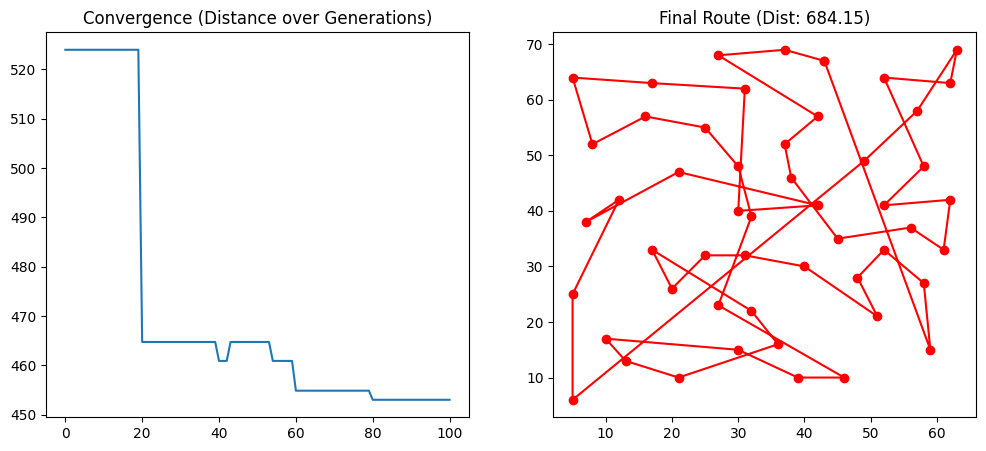

Phase 1: ACO Seeding for kroA100.tsp...
Phase 2: GA Refining for kroA100.tsp...
Final Hybrid Result: 26574.06


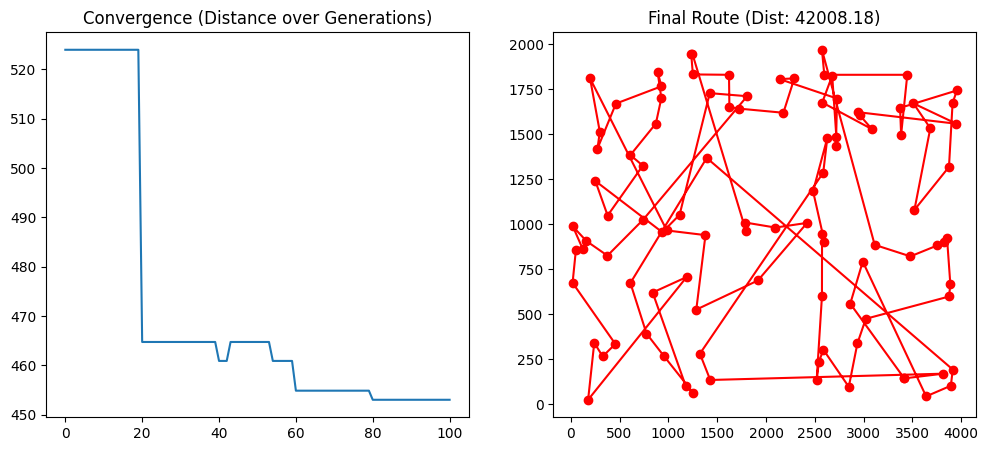

Phase 1: ACO Seeding for pcb442.tsp...
Phase 2: GA Refining for pcb442.tsp...
Final Hybrid Result: 79017.31


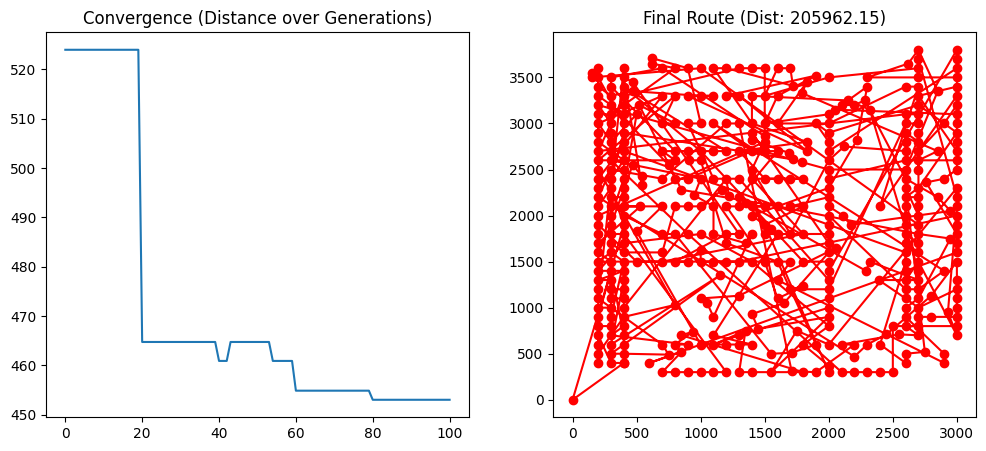

Phase 1: ACO Seeding for rat99.tsp...
Phase 2: GA Refining for rat99.tsp...
Final Hybrid Result: 1508.65


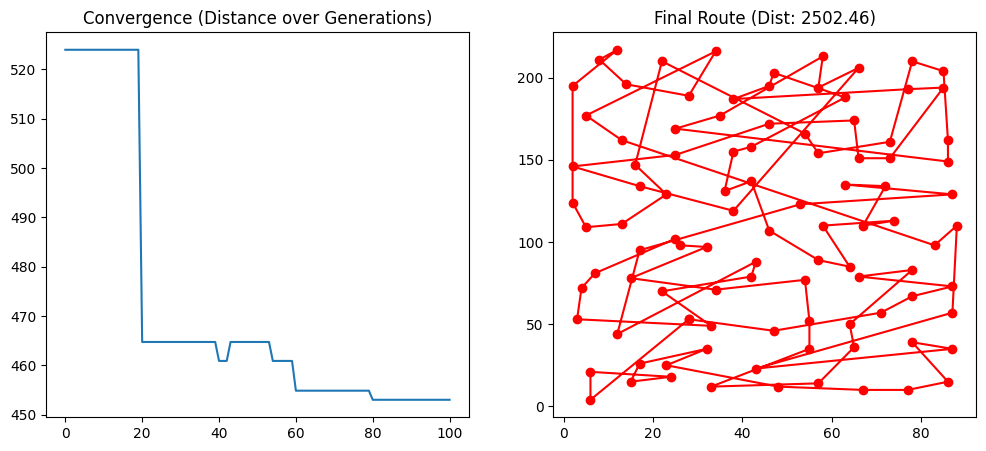

In [ ]:
import matplotlib.pyplot as plt
for data_file in datasets:
    file_name = os.path.basename(data_file)
    cities = load_tsplib_dataset(data_file)
    DIST_MATRIX = get_dist_matrix(cities)

    # 1. Start with ACO
    print(f"Phase 1: ACO Seeding for {file_name}...")
    aco_path = get_aco_seed(DIST_MATRIX)

    # 2. Seed GA Population
    # We take the ACO path and create 50 variations of it
    pop_size = 100
    population = []
    population.append(aco_path) # The original ACO winner
    for _ in range(pop_size - 1):
        # Add slight variations (Mutated Seeds)
        population.append(inversion_mutation(aco_path[:]))

    # 3. Run GA Refinement
    print(f"Phase 2: GA Refining for {file_name}...")
    for gen in range(50): # 50 generations is enough with a good seed
        new_pop = []
        # Keep the best one (Elitism)
        new_pop.append(min(population, key=calc_total_dist))

        while len(new_pop) < pop_size:
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)
            child = cyclic_crossover(parent1, parent2)
            child = inversion_mutation(child)
            new_pop.append(child)

        population = new_pop

    # 4. Final Polish with 2-opt
    best_ever = min(population, key=calc_total_dist)
    final_path = two_opt(best_ever)

    print(f"Final Hybrid Result: {calc_total_dist(final_path):.2f}")

    best_final = min(population, key=calc_total_dist)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history)
    plt.title("Convergence (Distance over Generations)")
    plt.subplot(1, 2, 2)
    coords = cities[best_final + [best_final[0]]]
    plt.plot(coords[:,0], coords[:,1], 'ro-')
    plt.title(f"Final Route (Dist: {calc_total_dist(best_final):.2f})")
    plt.show()



In [ ]:
for data_file in datasets:
    file_name = os.path.basename(data_file)
    cities = load_tsplib_dataset(data_file)
    DIST_MATRIX = get_dist_matrix(cities)

    # 1. Start with ACO
    print(f"Phase 1: ACO Seeding for {file_name}...")
    aco_path = get_aco_seed(DIST_MATRIX)

    # 2. Seed GA Population
    # We take the ACO path and create 50 variations of it
    pop_size = 100
    population = []
    population.append(aco_path) # The original ACO winner
    for _ in range(pop_size - 1):
        # Add slight variations (Mutated Seeds)
        population.append(inversion_mutation(aco_path[:]))

    # 3. Run GA Refinement
    print(f"Phase 2: GA Refining for {file_name}...")
    for gen in range(50): # 50 generations is enough with a good seed
        new_pop = []
        # Keep the best one (Elitism)
        new_pop.append(min(population, key=calc_total_dist))

        while len(new_pop) < pop_size:
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)
            child = cyclic_crossover(parent1, parent2)
            child = inversion_mutation(child)
            new_pop.append(child)

        population = new_pop

    # 4. Final Polish with 2-opt
    best_ever = min(population, key=calc_total_dist)
    final_path = two_opt(best_ever)

    print(f"Final Hybrid Result: {calc_total_dist(final_path):.2f}")

Phase 1: ACO Seeding for eil51.tsp...
Phase 2: GA Refining for eil51.tsp...
Final Hybrid Result: 463.72
Phase 1: ACO Seeding for kroA100.tsp...
Phase 2: GA Refining for kroA100.tsp...
Final Hybrid Result: 27578.63
Phase 1: ACO Seeding for pcb442.tsp...
Phase 2: GA Refining for pcb442.tsp...
Final Hybrid Result: 77531.36
Phase 1: ACO Seeding for rat99.tsp...
Phase 2: GA Refining for rat99.tsp...
Final Hybrid Result: 1540.61



Processing eil51.tsp...


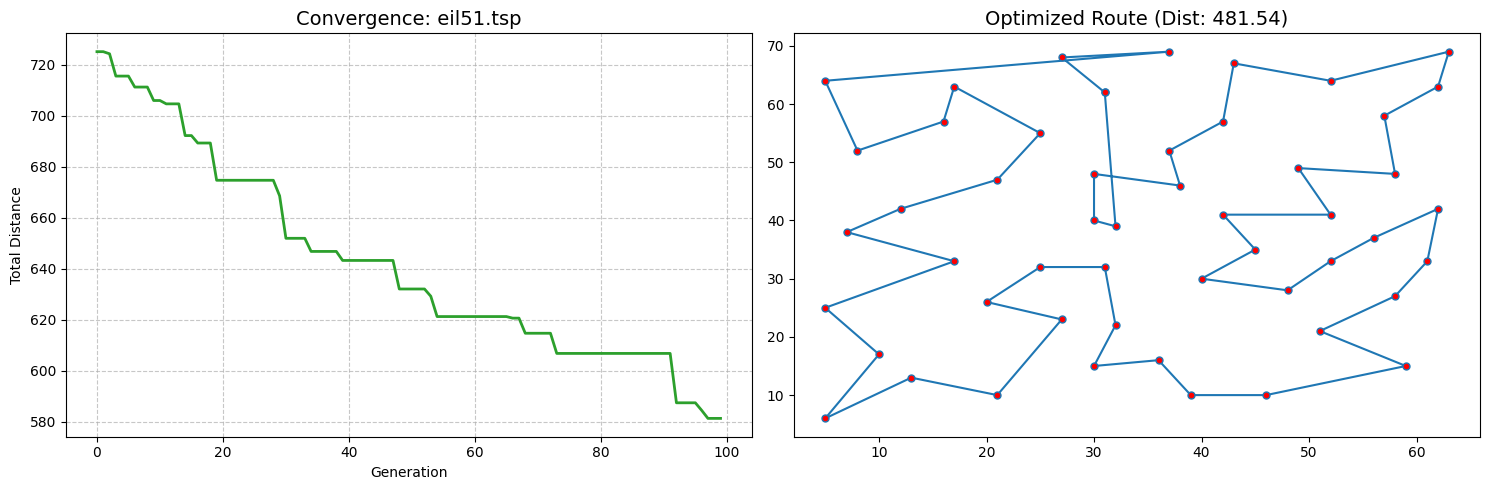


Processing kroA100.tsp...


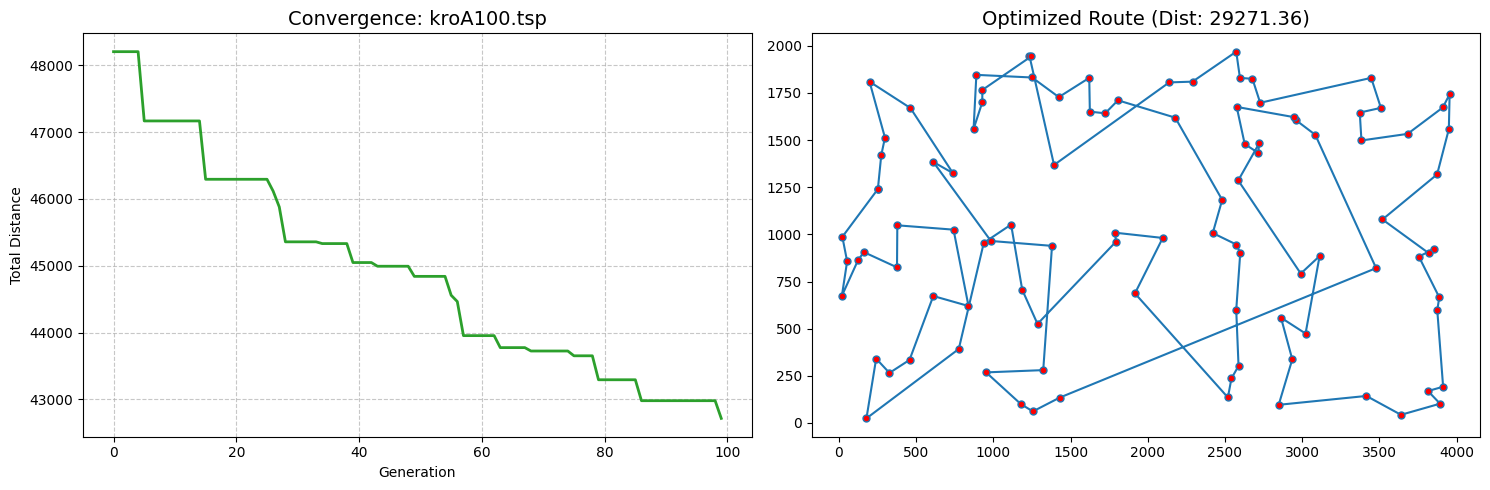


Processing pcb442.tsp...


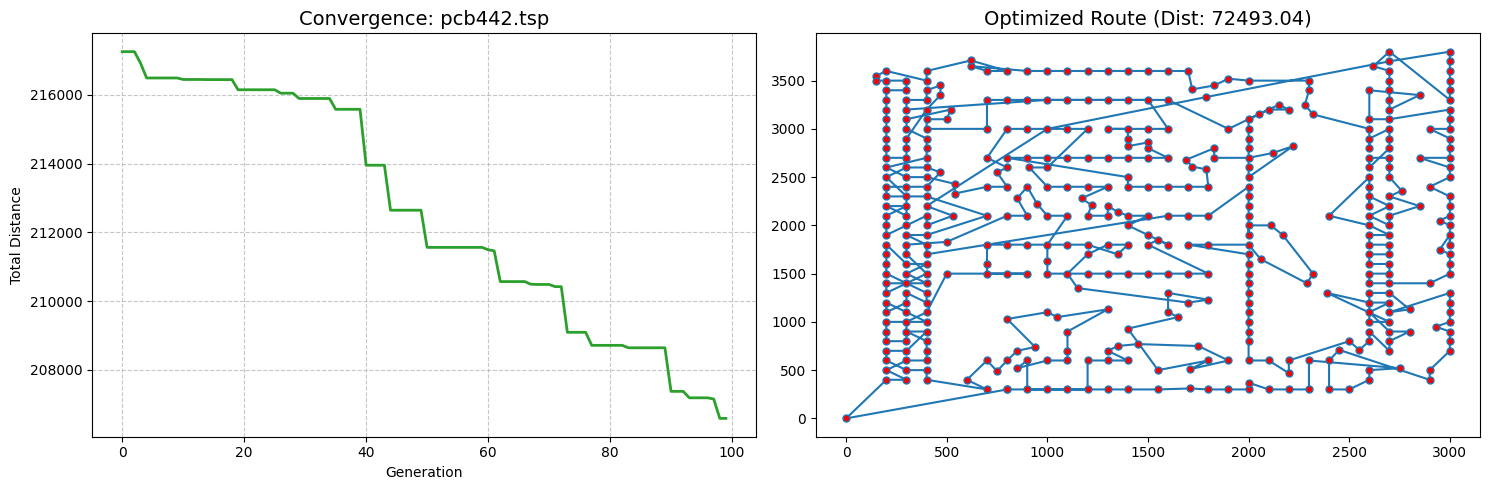


Processing rat99.tsp...


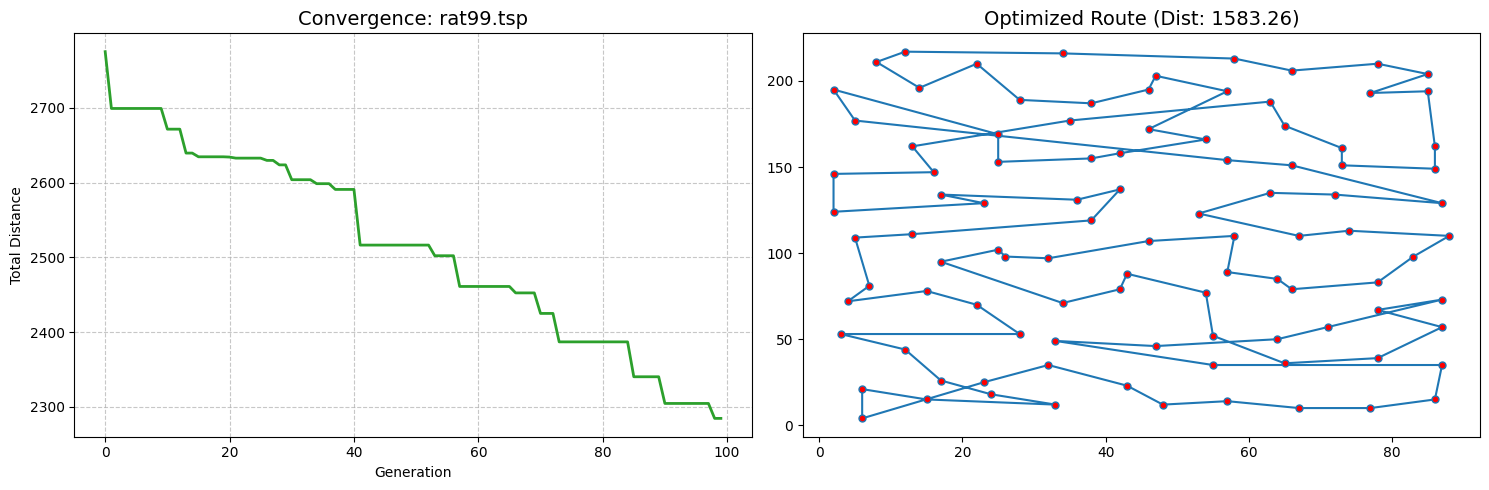


Dataset         | Final Distance 
---------------------------------
eil51.tsp       | 481.54         
kroA100.tsp     | 29271.36       
pcb442.tsp      | 72493.04       
rat99.tsp       | 1583.26        


In [ ]:
import os
import matplotlib.pyplot as plt

# --- EXPERIMENT LOOP ---
results_table = []

for data_file in datasets:
    file_name = os.path.basename(data_file)
    cities = load_tsplib_dataset(data_file)
    DIST_MATRIX = get_dist_matrix(cities)

    # 1. ACO SEEDING
    print(f"\nProcessing {file_name}...")
    aco_path = get_aco_seed(DIST_MATRIX)

    # 2. INITIALIZE POPULATION
    pop_size = 100
    population = [inversion_mutation(aco_path[:]) for _ in range(pop_size)]

    # 3. GA REFINEMENT (WITH HISTORY TRACKING)
    history = []
    for gen in range(100): # Increased to 100 for better visualization
        # Elitism
        best_current = min(population, key=calc_total_dist)
        history.append(calc_total_dist(best_current))

        new_pop = [best_current]
        while len(new_pop) < pop_size:
            p1, p2 = tournament_selection(population), tournament_selection(population)
            child = inversion_mutation(cyclic_crossover(p1, p2))
            new_pop.append(child)
        population = new_pop

    # 4. FINAL POLISH
    best_ever = min(population, key=calc_total_dist)
    final_path = two_opt(best_ever)
    final_dist = calc_total_dist(final_path)

    # 5. CLEAN PRESENTATION PLOTS
    plt.figure(figsize=(15, 5))

    # Plot 1: Convergence
    plt.subplot(1, 2, 1)
    plt.plot(history, color='#2ca02c', linewidth=2)
    plt.title(f"Convergence: {file_name}", fontsize=14)
    plt.xlabel("Generation")
    plt.ylabel("Total Distance")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Final Route
    plt.subplot(1, 2, 2)
    path_coords = cities[final_path + [final_path[0]]]
    plt.plot(path_coords[:,0], path_coords[:,1], 'o-', markersize=5, color='#1f77b4', mfc='red')
    plt.title(f"Optimized Route (Dist: {final_dist:.2f})", fontsize=14)

    plt.tight_layout()
    plt.show()

    results_table.append((file_name, final_dist))

# 6. SUMMARY TABLE
print("\n" + "="*30)
print(f"{'Dataset':<15} | {'Final Distance':<15}")
print("-" * 33)
for name, dist in results_table:
    print(f"{name:<15} | {dist:<15.2f}")


Processing eil51.tsp...


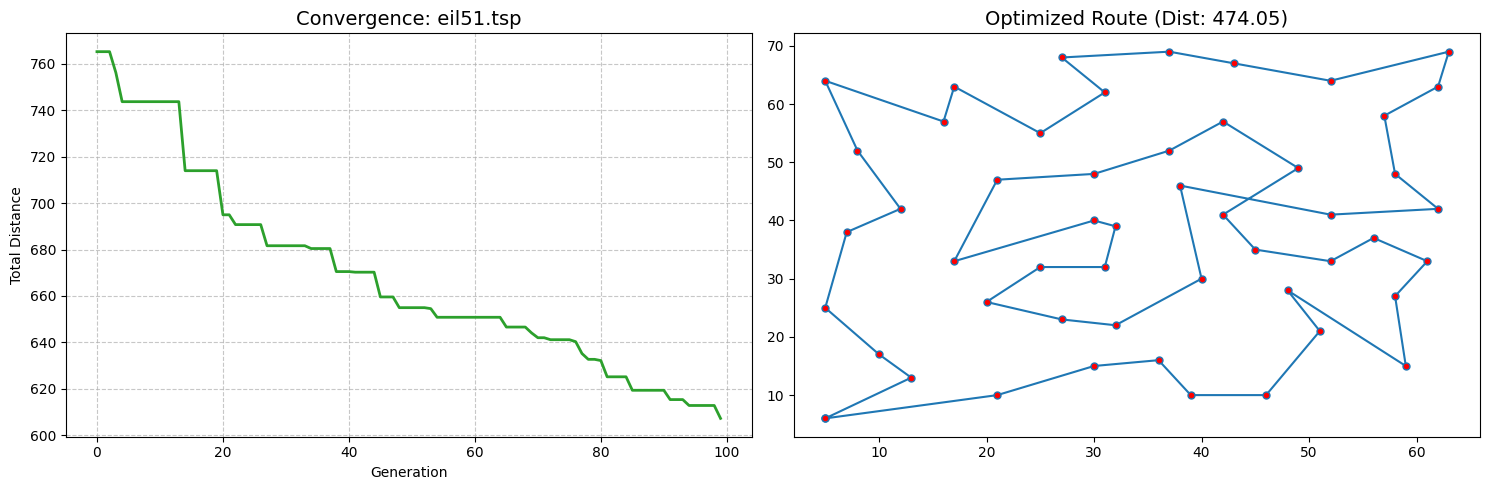


Processing kroA100.tsp...


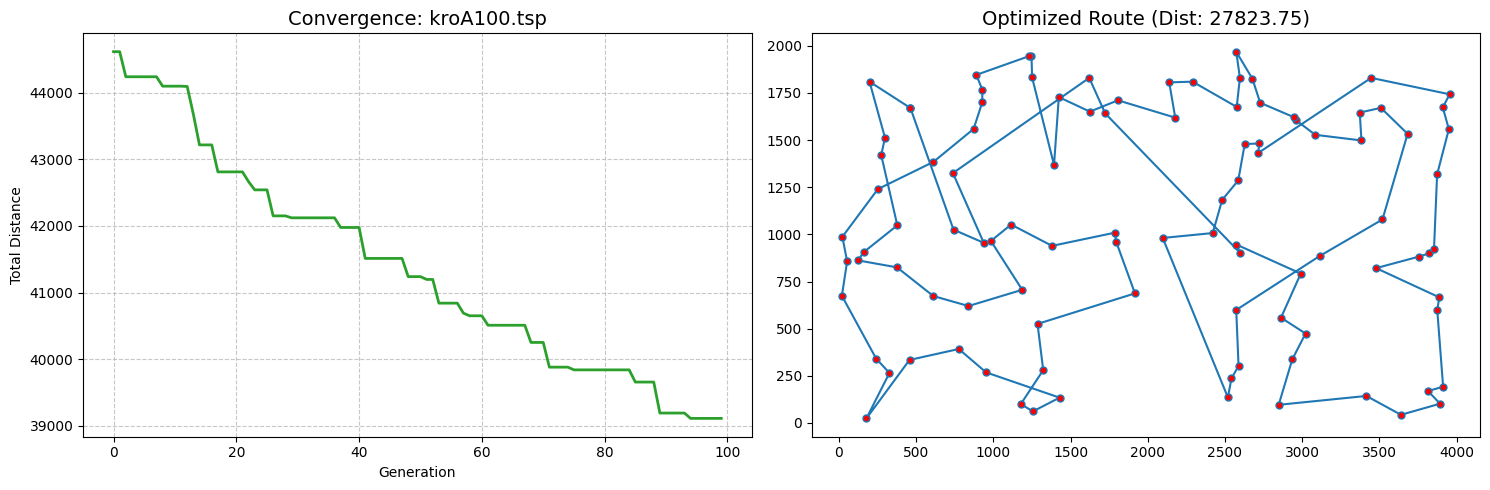


Processing pcb442.tsp...


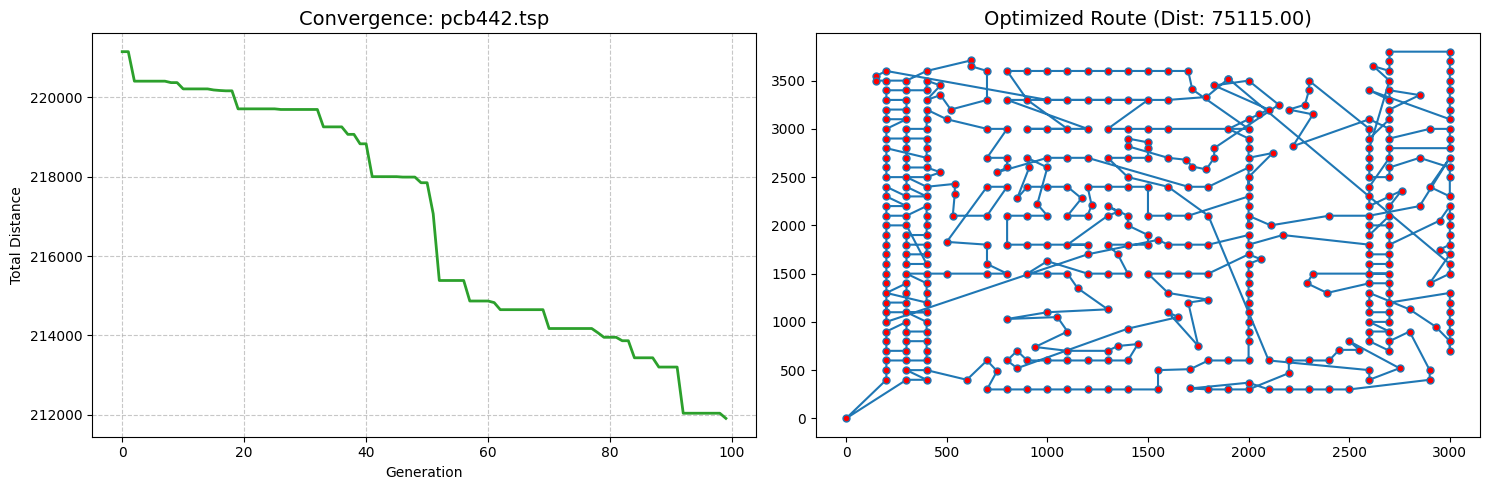


Processing rat99.tsp...


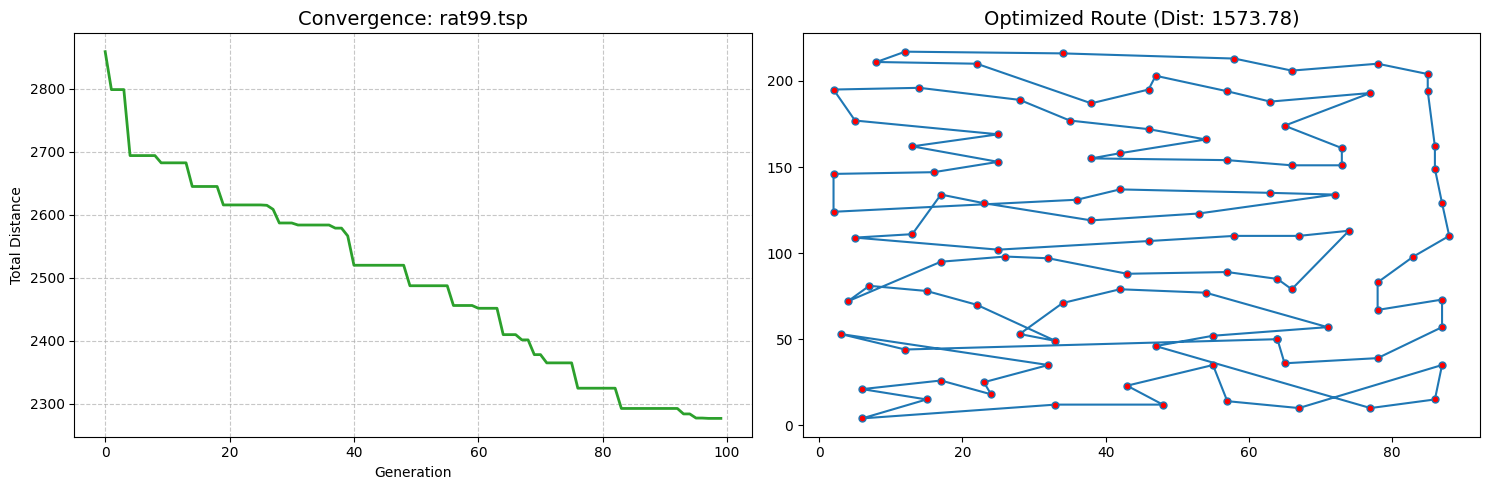


Dataset         | Final Distance 
---------------------------------
eil51.tsp       | 474.05         
kroA100.tsp     | 27823.75       
pcb442.tsp      | 75115.00       
rat99.tsp       | 1573.78        


In [ ]:
import os
import matplotlib.pyplot as plt

# --- EXPERIMENT LOOP ---
results_table = []

for data_file in datasets:
    file_name = os.path.basename(data_file)
    cities = load_tsplib_dataset(data_file)
    DIST_MATRIX = get_dist_matrix(cities)

    # 1. ACO SEEDING
    print(f"\nProcessing {file_name}...")
    aco_path = get_aco_seed(DIST_MATRIX)

    # 2. INITIALIZE POPULATION
    pop_size = 100
    population = [inversion_mutation(aco_path[:]) for _ in range(pop_size)]

    # 3. GA REFINEMENT (WITH HISTORY TRACKING)
    history = []
    for gen in range(100): # Increased to 100 for better visualization
        # Elitism
        best_current = min(population, key=calc_total_dist)
        history.append(calc_total_dist(best_current))

        new_pop = [best_current]
        while len(new_pop) < pop_size:
            p1, p2 = tournament_selection(population), tournament_selection(population)
            child = inversion_mutation(cyclic_crossover(p1, p2))
            new_pop.append(child)
        population = new_pop

    # 4. FINAL POLISH
    best_ever = min(population, key=calc_total_dist)
    final_path = two_opt(best_ever)
    final_dist = calc_total_dist(final_path)

    # 5. CLEAN PRESENTATION PLOTS
    plt.figure(figsize=(15, 5))

    # Plot 1: Convergence
    plt.subplot(1, 2, 1)
    plt.plot(history, color='#2ca02c', linewidth=2)
    plt.title(f"Convergence: {file_name}", fontsize=14)
    plt.xlabel("Generation")
    plt.ylabel("Total Distance")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Final Route
    plt.subplot(1, 2, 2)
    path_coords = cities[final_path + [final_path[0]]]
    plt.plot(path_coords[:,0], path_coords[:,1], 'o-', markersize=5, color='#1f77b4', mfc='red')
    plt.title(f"Optimized Route (Dist: {final_dist:.2f})", fontsize=14)

    plt.tight_layout()
    plt.show()

    results_table.append((file_name, final_dist))

# 6. SUMMARY TABLE
print("\n" + "="*30)
print(f"{'Dataset':<15} | {'Final Distance':<15}")
print("-" * 33)
for name, dist in results_table:
    print(f"{name:<15} | {dist:<15.2f}")


Processing eil51.tsp...


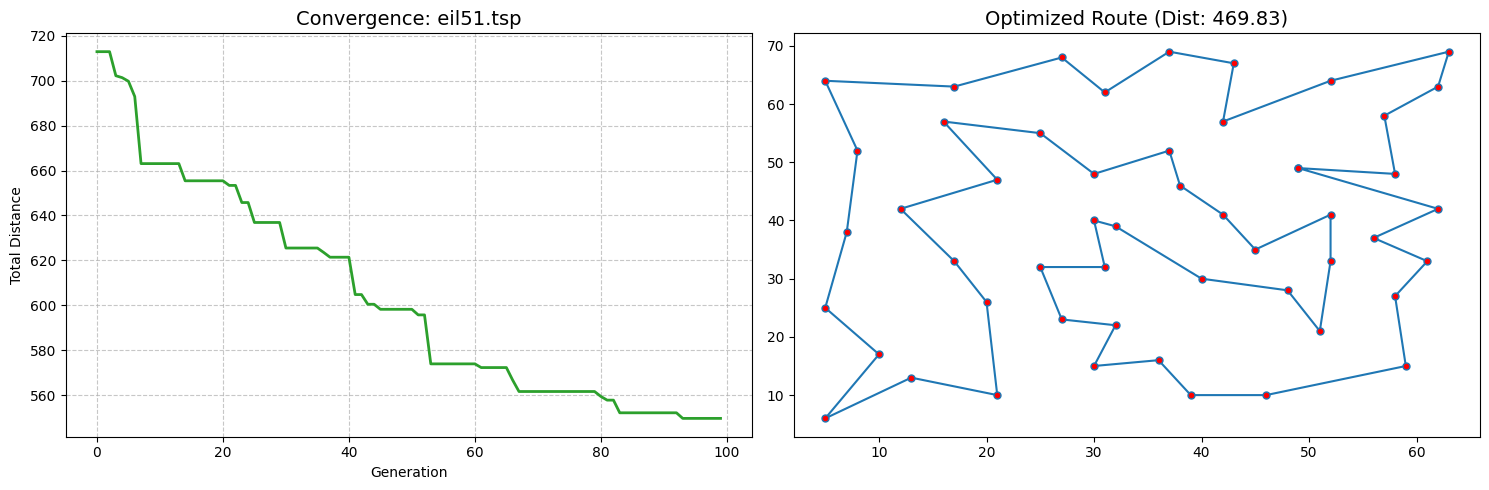


Processing kroA100.tsp...


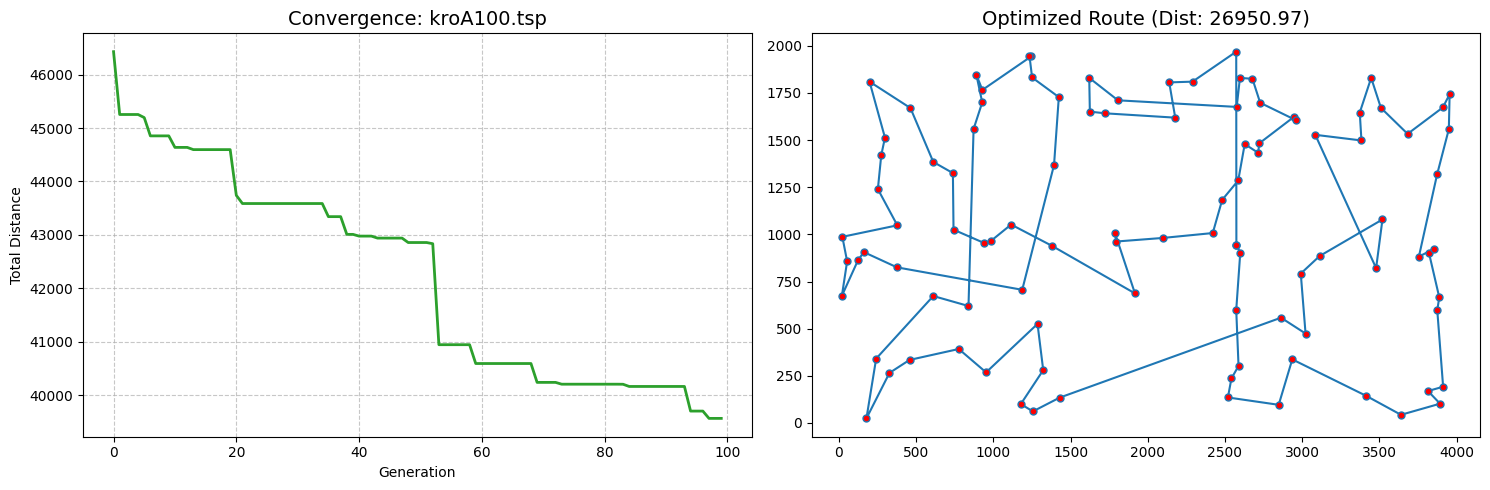


Processing pcb442.tsp...


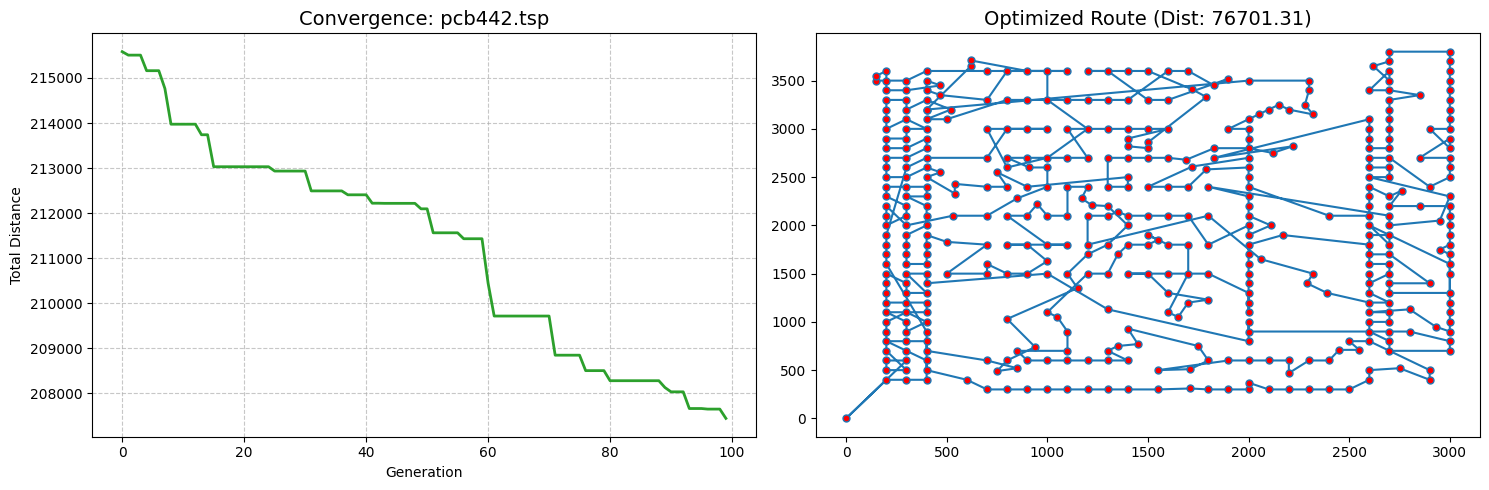


Processing rat99.tsp...


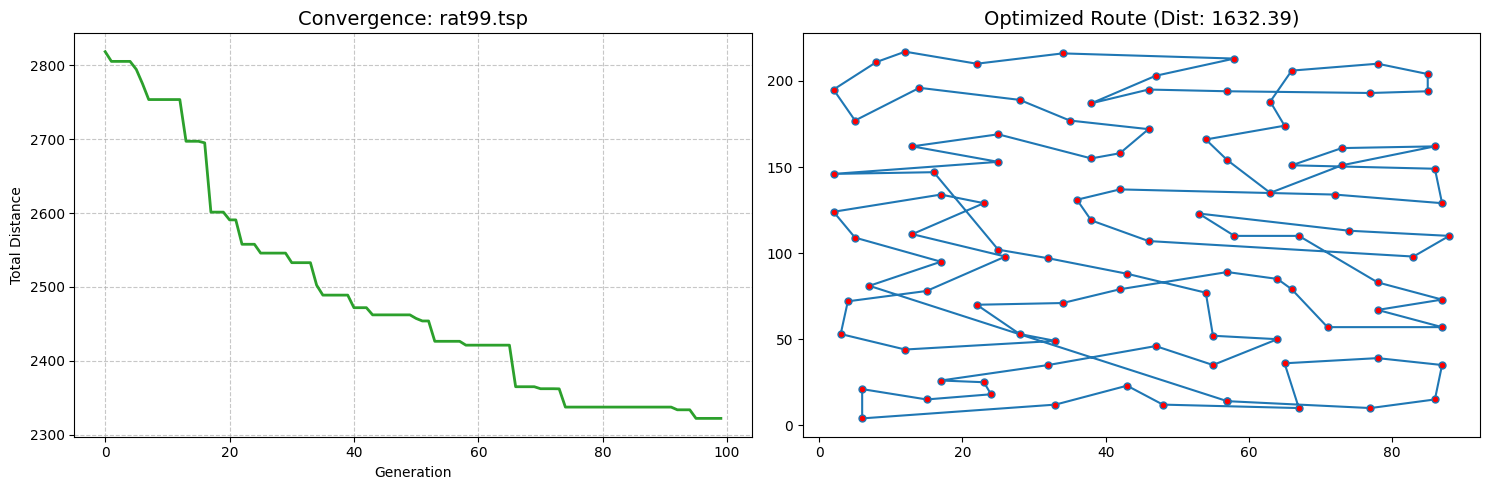


Dataset         | Final Distance 
---------------------------------
eil51.tsp       | 469.83         
kroA100.tsp     | 26950.97       
pcb442.tsp      | 76701.31       
rat99.tsp       | 1632.39        


In [ ]:
import os
import matplotlib.pyplot as plt

# --- EXPERIMENT LOOP ---
results_table = []

for data_file in datasets:
    file_name = os.path.basename(data_file)
    cities = load_tsplib_dataset(data_file)
    DIST_MATRIX = get_dist_matrix(cities)

    # 1. ACO SEEDING
    print(f"\nProcessing {file_name}...")
    aco_path = get_aco_seed(DIST_MATRIX)

    # 2. INITIALIZE POPULATION
    pop_size = 100
    population = [inversion_mutation(aco_path[:]) for _ in range(pop_size)]

    # 3. GA REFINEMENT (WITH HISTORY TRACKING)
    history = []
    for gen in range(100): # Increased to 100 for better visualization
        # Elitism
        best_current = min(population, key=calc_total_dist)
        history.append(calc_total_dist(best_current))

        new_pop = [best_current]
        while len(new_pop) < pop_size:
            p1, p2 = tournament_selection(population), tournament_selection(population)
            child = inversion_mutation(cyclic_crossover(p1, p2))
            new_pop.append(child)
        population = new_pop

    # 4. FINAL POLISH
    best_ever = min(population, key=calc_total_dist)
    final_path = two_opt(best_ever)
    final_dist = calc_total_dist(final_path)

    # 5. CLEAN PRESENTATION PLOTS
    plt.figure(figsize=(15, 5))

    # Plot 1: Convergence
    plt.subplot(1, 2, 1)
    plt.plot(history, color='#2ca02c', linewidth=2)
    plt.title(f"Convergence: {file_name}", fontsize=14)
    plt.xlabel("Generation")
    plt.ylabel("Total Distance")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Final Route
    plt.subplot(1, 2, 2)
    path_coords = cities[final_path + [final_path[0]]]
    plt.plot(path_coords[:,0], path_coords[:,1], 'o-', markersize=5, color='#1f77b4', mfc='red')
    plt.title(f"Optimized Route (Dist: {final_dist:.2f})", fontsize=14)

    plt.tight_layout()
    plt.show()

    results_table.append((file_name, final_dist))

# 6. SUMMARY TABLE
print("\n" + "="*30)
print(f"{'Dataset':<15} | {'Final Distance':<15}")
print("-" * 33)
for name, dist in results_table:
    print(f"{name:<15} | {dist:<15.2f}")


Processing eil51.tsp...


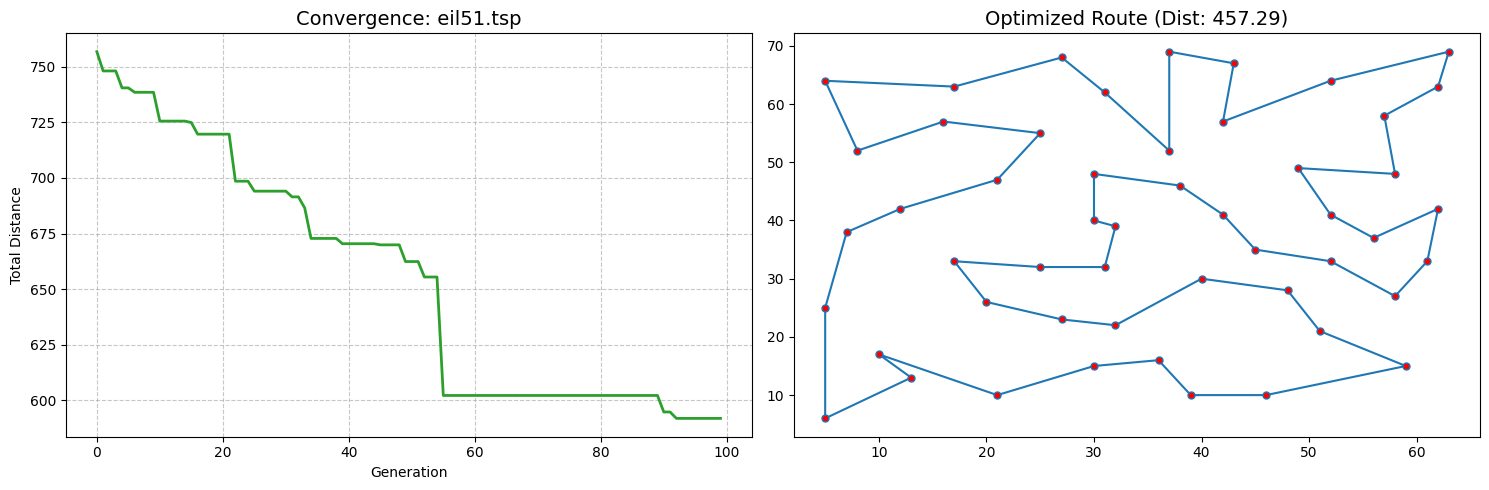


Processing kroA100.tsp...


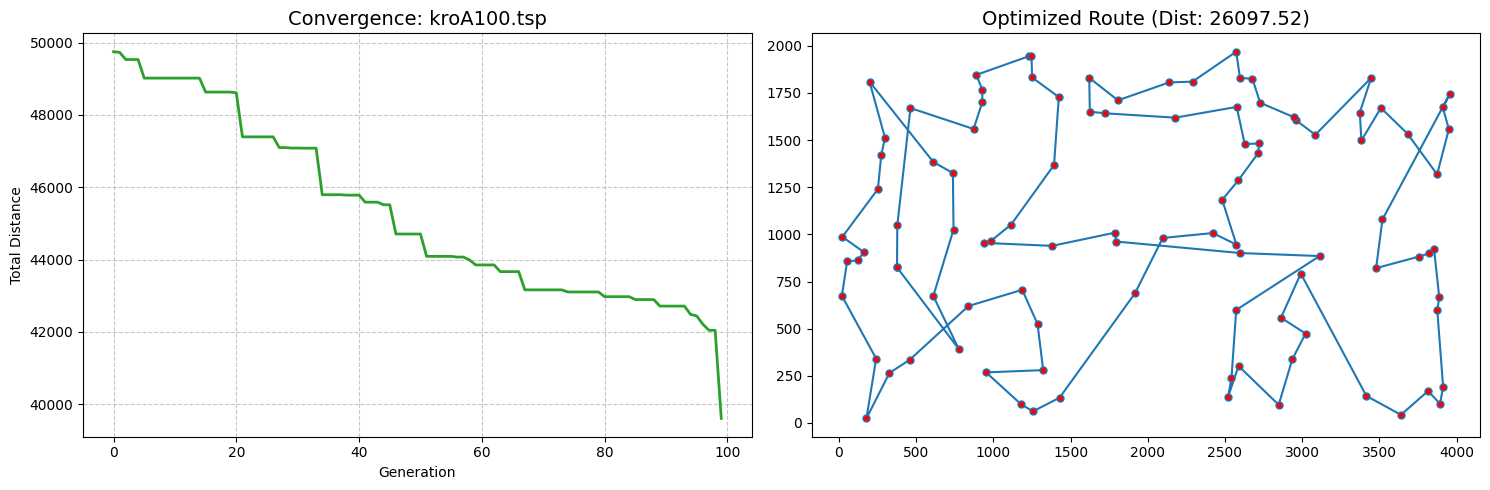


Processing pcb442.tsp...


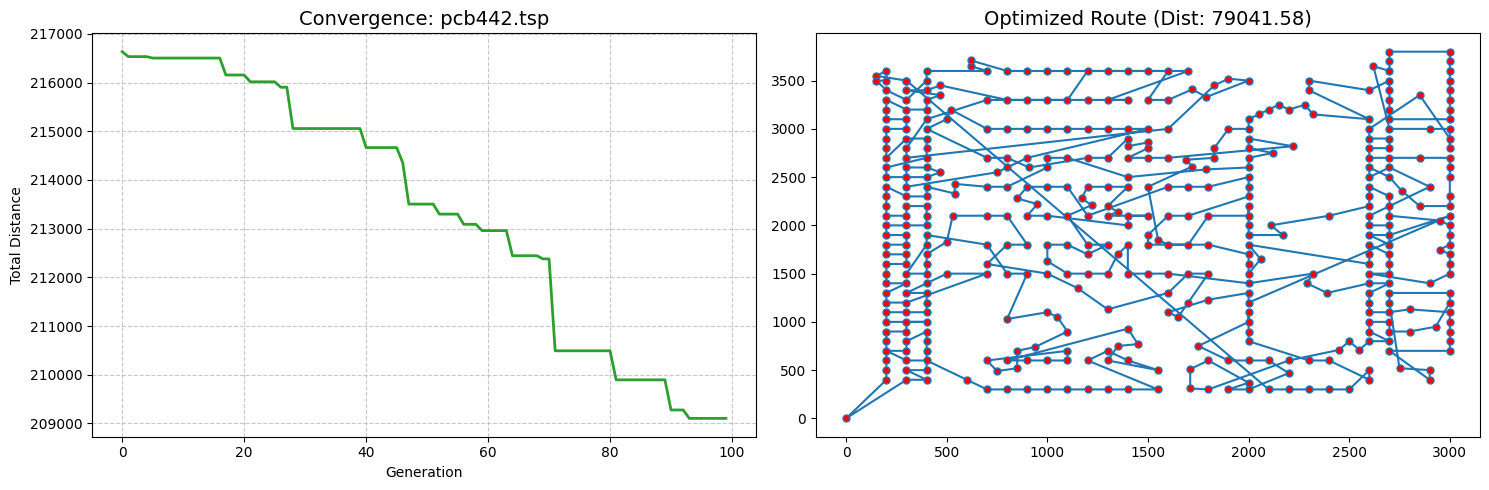


Processing rat99.tsp...


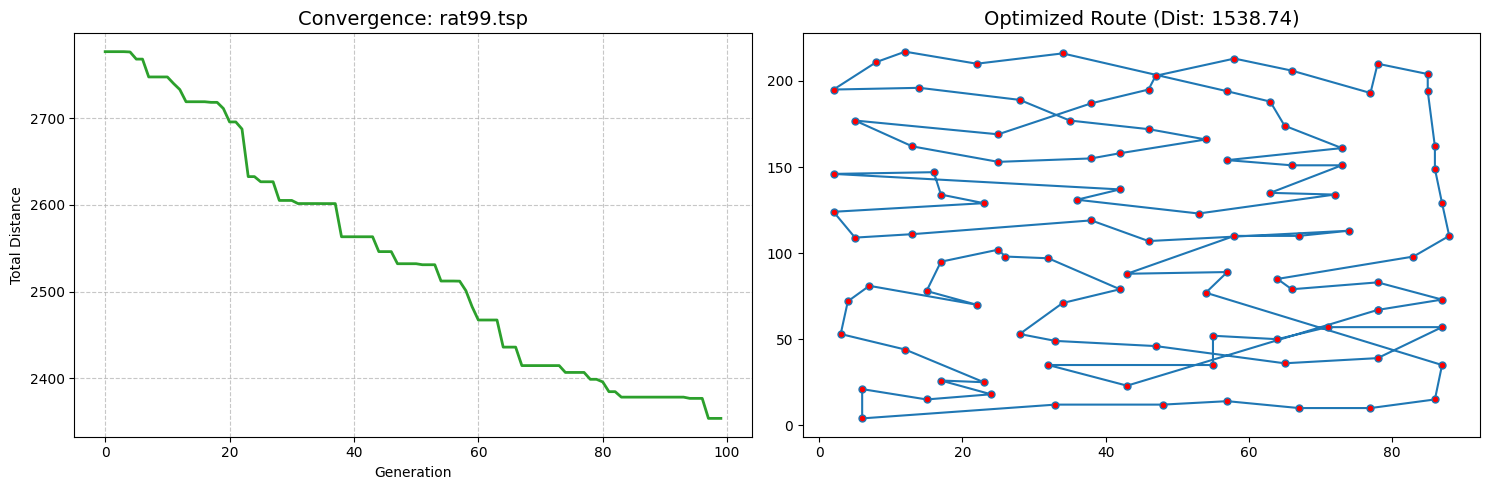


Dataset         | Final Distance 
---------------------------------
eil51.tsp       | 457.29         
kroA100.tsp     | 26097.52       
pcb442.tsp      | 79041.58       
rat99.tsp       | 1538.74        


In [ ]:
import os
import matplotlib.pyplot as plt

# --- EXPERIMENT LOOP ---
results_table = []

for data_file in datasets:
    file_name = os.path.basename(data_file)
    cities = load_tsplib_dataset(data_file)
    DIST_MATRIX = get_dist_matrix(cities)

    # 1. ACO SEEDING
    print(f"\nProcessing {file_name}...")
    aco_path = get_aco_seed(DIST_MATRIX)

    # 2. INITIALIZE POPULATION
    pop_size = 100
    population = [inversion_mutation(aco_path[:]) for _ in range(pop_size)]

    # 3. GA REFINEMENT (WITH HISTORY TRACKING)
    history = []
    for gen in range(100): # Increased to 100 for better visualization
        # Elitism
        best_current = min(population, key=calc_total_dist)
        history.append(calc_total_dist(best_current))

        new_pop = [best_current]
        while len(new_pop) < pop_size:
            p1, p2 = tournament_selection(population), tournament_selection(population)
            child = inversion_mutation(cyclic_crossover(p1, p2))
            new_pop.append(child)
        population = new_pop

    # 4. FINAL POLISH
    best_ever = min(population, key=calc_total_dist)
    final_path = two_opt(best_ever)
    final_dist = calc_total_dist(final_path)

    # 5. CLEAN PRESENTATION PLOTS
    plt.figure(figsize=(15, 5))

    # Plot 1: Convergence
    plt.subplot(1, 2, 1)
    plt.plot(history, color='#2ca02c', linewidth=2)
    plt.title(f"Convergence: {file_name}", fontsize=14)
    plt.xlabel("Generation")
    plt.ylabel("Total Distance")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Final Route
    plt.subplot(1, 2, 2)
    path_coords = cities[final_path + [final_path[0]]]
    plt.plot(path_coords[:,0], path_coords[:,1], 'o-', markersize=5, color='#1f77b4', mfc='red')
    plt.title(f"Optimized Route (Dist: {final_dist:.2f})", fontsize=14)

    plt.tight_layout()
    plt.show()

    results_table.append((file_name, final_dist))

# 6. SUMMARY TABLE
print("\n" + "="*30)
print(f"{'Dataset':<15} | {'Final Distance':<15}")
print("-" * 33)
for name, dist in results_table:
    print(f"{name:<15} | {dist:<15.2f}")


Processing eil51.tsp...


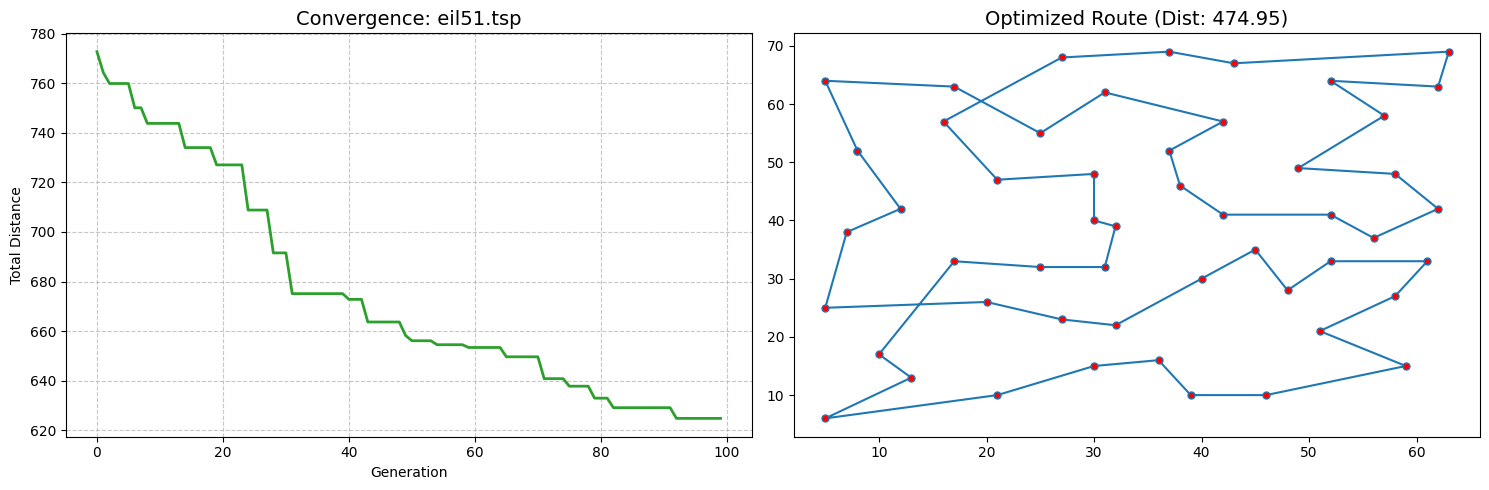


Processing kroA100.tsp...


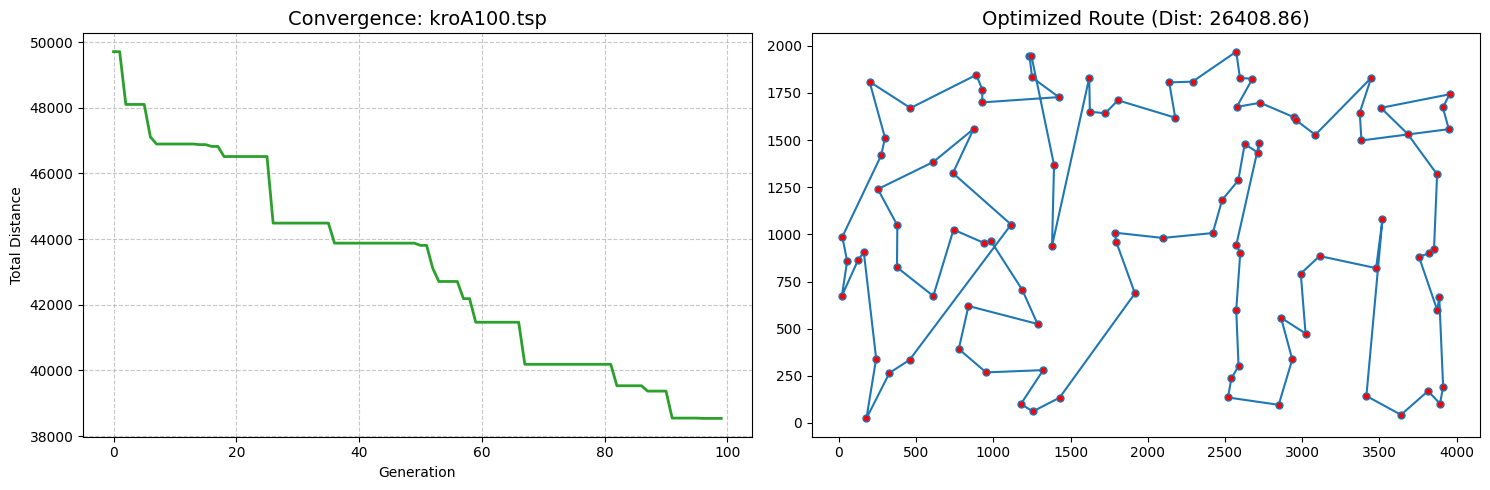


Processing pcb442.tsp...


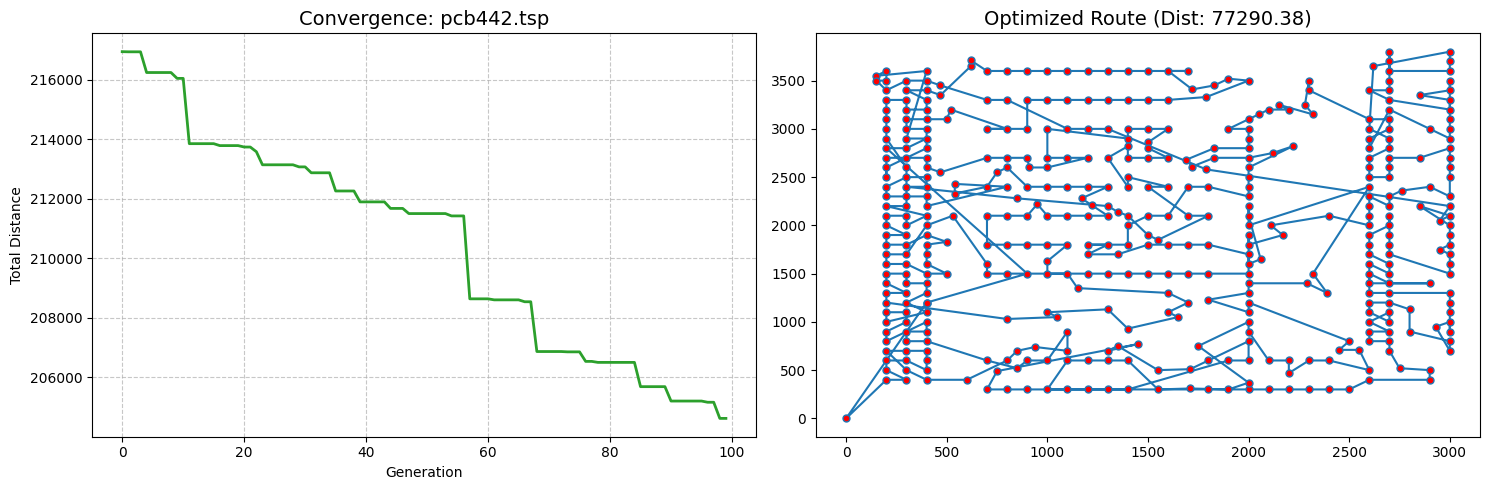


Processing rat99.tsp...


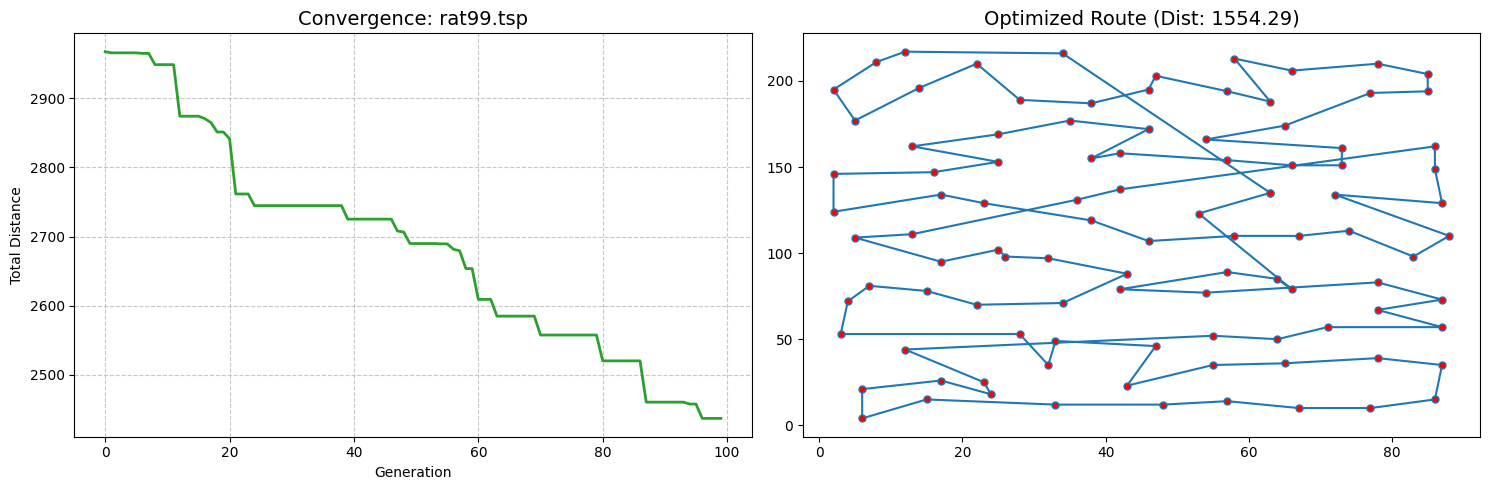


Dataset         | Final Distance 
---------------------------------
eil51.tsp       | 474.95         
kroA100.tsp     | 26408.86       
pcb442.tsp      | 77290.38       
rat99.tsp       | 1554.29        


In [ ]:
import os
import matplotlib.pyplot as plt

# --- EXPERIMENT LOOP ---
results_table = []

for data_file in datasets:
    file_name = os.path.basename(data_file)
    cities = load_tsplib_dataset(data_file)
    DIST_MATRIX = get_dist_matrix(cities)

    # 1. ACO SEEDING
    print(f"\nProcessing {file_name}...")
    aco_path = get_aco_seed(DIST_MATRIX)

    # 2. INITIALIZE POPULATION
    pop_size = 100
    population = [inversion_mutation(aco_path[:]) for _ in range(pop_size)]

    # 3. GA REFINEMENT (WITH HISTORY TRACKING)
    history = []
    for gen in range(100): # Increased to 100 for better visualization
        # Elitism
        best_current = min(population, key=calc_total_dist)
        history.append(calc_total_dist(best_current))

        new_pop = [best_current]
        while len(new_pop) < pop_size:
            p1, p2 = tournament_selection(population), tournament_selection(population)
            child = inversion_mutation(cyclic_crossover(p1, p2))
            new_pop.append(child)
        population = new_pop

    # 4. FINAL POLISH
    best_ever = min(population, key=calc_total_dist)
    final_path = two_opt(best_ever)
    final_dist = calc_total_dist(final_path)

    # 5. CLEAN PRESENTATION PLOTS
    plt.figure(figsize=(15, 5))

    # Plot 1: Convergence
    plt.subplot(1, 2, 1)
    plt.plot(history, color='#2ca02c', linewidth=2)
    plt.title(f"Convergence: {file_name}", fontsize=14)
    plt.xlabel("Generation")
    plt.ylabel("Total Distance")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Final Route
    plt.subplot(1, 2, 2)
    path_coords = cities[final_path + [final_path[0]]]
    plt.plot(path_coords[:,0], path_coords[:,1], 'o-', markersize=5, color='#1f77b4', mfc='red')
    plt.title(f"Optimized Route (Dist: {final_dist:.2f})", fontsize=14)

    plt.tight_layout()
    plt.show()

    results_table.append((file_name, final_dist))

# 6. SUMMARY TABLE
print("\n" + "="*30)
print(f"{'Dataset':<15} | {'Final Distance':<15}")
print("-" * 33)
for name, dist in results_table:
    print(f"{name:<15} | {dist:<15.2f}")